## **1. Imports et configuration**

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
gpd.options.io_engine = "pyogrio"
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path.cwd().parent
PROVINCES_GPKG = PROJECT_ROOT / "data" / "processed" / "pilot_provinces_enriched.gpkg"
PARCELS_GPKG = PROJECT_ROOT / "data" / "synthetic" / "parcelles_synthetiques.gpkg"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("Fichier parcelles existe :", PARCELS_GPKG.exists())

PROJECT_ROOT : c:\Users\engoy\OneDrive - TFM\Desktop\DS Cadastre\projet_foncier_lualaba
Fichier parcelles existe : True


## **2. Charger les données**

In [3]:
# Charger les provinces
provinces = gpd.read_file(PROVINCES_GPKG, layer="provinces")

# Charger les parcelles
parcelles = gpd.read_file(PARCELS_GPKG, layer="parcelles")

print(f"Provinces : {len(provinces)}")
print(f"Parcelles : {len(parcelles):,}")
print(f"\nColonnes parcelles :")
print(parcelles.columns.tolist())
print(f"\nAperçu :")
parcelles.head(3)

Provinces : 4
Parcelles : 57,000

Colonnes parcelles :
['id_parcelle', 'province', 'profile', 'latitude', 'longitude', 'superficie_m2', 'statut', 'sous_influence_miniere', 'distance_centre_km', 'valeur_usd', 'type_titre', 'date_enregistrement', 'geometry']

Aperçu :


,id_parcelle,province,profile,latitude,longitude,superficie_m2,statut,sous_influence_miniere,distance_centre_km,valeur_usd,type_titre,date_enregistrement,geometry
0,HK-000001,Haut-Katanga,mining_urban,-9.963835,28.651323,347.57,formel,False,105.22,349.16,certificat,2022-02-10,POINT (28.65132 -9.96384)
1,HK-000002,Haut-Katanga,mining_urban,-8.439696,27.503674,347.58,litigieux,True,226.19,66.79,certificat,2021-01-30,POINT (27.50367 -8.4397)
2,HK-000003,Haut-Katanga,mining_urban,-11.637689,28.350721,2118.48,formel,False,143.63,2236.01,certificat,2021-04-20,POINT (28.35072 -11.63769)


## **3. Statistiques descriptives**

In [4]:
# Statistiques globales
print("=== Statistiques globales ===")
print(parcelles[["superficie_m2", "valeur_usd", "distance_centre_km"]].describe().round(2))

print("\n=== Distribution des statuts ===")
print(parcelles["statut"].value_counts())
print("\n(en %)")
print((parcelles["statut"].value_counts(normalize=True) * 100).round(2))

print("\n=== Distribution des types de titre ===")
print(parcelles["type_titre"].value_counts())

print("\n=== Influence minière ===")
print(parcelles["sous_influence_miniere"].value_counts())

=== Statistiques globales ===
       superficie_m2  valeur_usd  distance_centre_km
count       57000.00    57000.00            57000.00
mean         1284.20      559.46              156.42
std          1731.16     1141.05               73.36
min            32.96        5.75                0.92
25%           396.14      129.57              102.40
50%           727.58      264.66              151.41
75%          1483.66      570.82              202.51
max         57183.77    63324.98              396.79

=== Distribution des statuts ===
statut
litigieux    22447
formel       19598
informel     14955
Name: count, dtype: int64

(en %)
statut
litigieux    39.38
formel       34.38
informel     26.24
Name: proportion, dtype: float64

=== Distribution des types de titre ===
type_titre
occupation         28353
certificat         14931
titre_definitif    13716
Name: count, dtype: int64

=== Influence minière ===
sous_influence_miniere
False    32052
True     24948
Name: count, dtype: int64


## **4. Carte globale des parcelles**

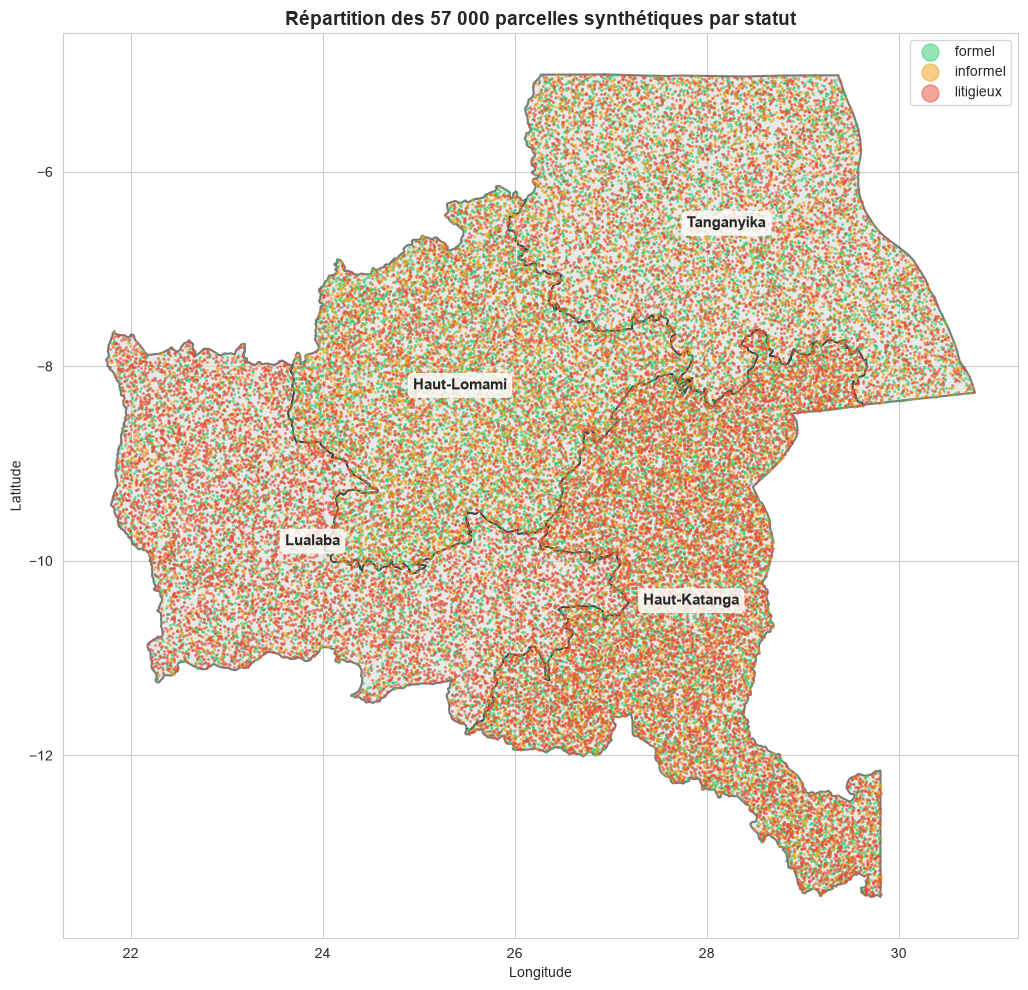

In [5]:
fig, ax = plt.subplots(figsize=(14, 10))

# Contours des provinces
provinces.plot(ax=ax, facecolor="lightgray", edgecolor="black", linewidth=1.5, alpha=0.5)

# Parcelles colorées par statut
colors = {"formel": "#2ecc71", "informel": "#f39c12", "litigieux": "#e74c3c"}
for statut, color in colors.items():
    subset = parcelles[parcelles["statut"] == statut]
    subset.plot(ax=ax, color=color, markersize=1.5, alpha=0.5, label=statut)

# Ajouter les noms des provinces
for _, row in provinces.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(row["adm1_name"], xy=(centroid.x, centroid.y),
                ha="center", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.set_title("Répartition des 57 000 parcelles synthétiques par statut", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", markerscale=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "carte_statuts.png", dpi=150, bbox_inches="tight")
plt.show()

## **5. Carte de l'influence minière**

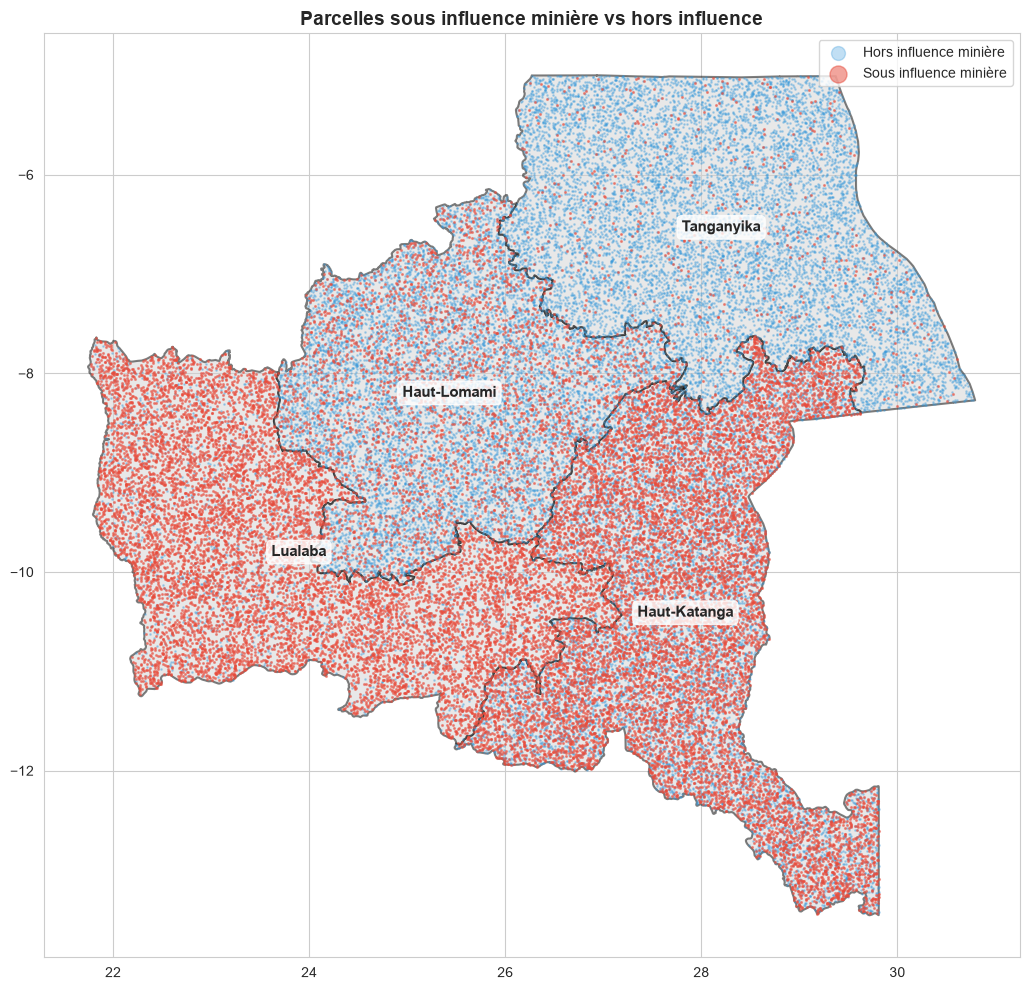

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

provinces.plot(ax=ax, facecolor="lightgray", edgecolor="black", linewidth=1.5, alpha=0.5)

# Parcelles hors influence minière (en bleu clair)
hors = parcelles[~parcelles["sous_influence_miniere"]]
hors.plot(ax=ax, color="#3498db", markersize=1, alpha=0.3, label="Hors influence minière")

# Parcelles sous influence minière (en rouge)
sous = parcelles[parcelles["sous_influence_miniere"]]
sous.plot(ax=ax, color="#e74c3c", markersize=1.5, alpha=0.5, label="Sous influence minière")

for _, row in provinces.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(row["adm1_name"], xy=(centroid.x, centroid.y),
                ha="center", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.set_title("Parcelles sous influence minière vs hors influence", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", markerscale=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "carte_influence_miniere.png", dpi=150, bbox_inches="tight")
plt.show()

## **6. Distribution des superficies par province**

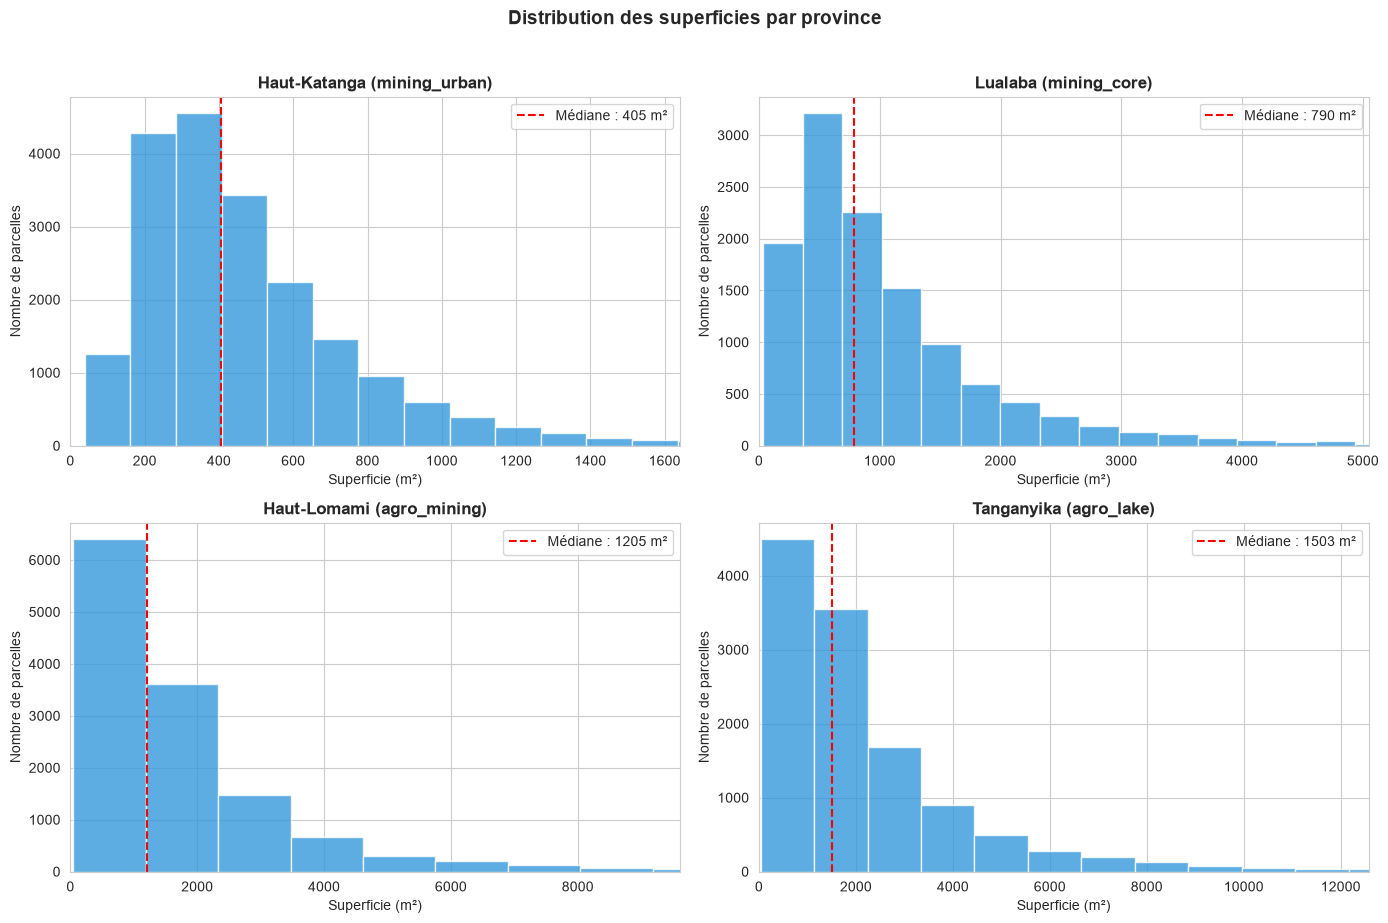

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, province in enumerate(parcelles["province"].unique()):
    subset = parcelles[parcelles["province"] == province]
    axes[i].hist(subset["superficie_m2"], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(subset["superficie_m2"].median(), color="red", linestyle="--",
                    label=f"Médiane : {subset['superficie_m2'].median():.0f} m²")
    axes[i].set_title(f"{province} ({subset['profile'].iloc[0]})", fontweight="bold")
    axes[i].set_xlabel("Superficie (m²)")
    axes[i].set_ylabel("Nombre de parcelles")
    axes[i].legend()
    axes[i].set_xlim(0, subset["superficie_m2"].quantile(0.99))

plt.suptitle("Distribution des superficies par province", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "distribution_superficies.png", dpi=150, bbox_inches="tight")
plt.show()

## **7. Distribution des valeurs foncières**

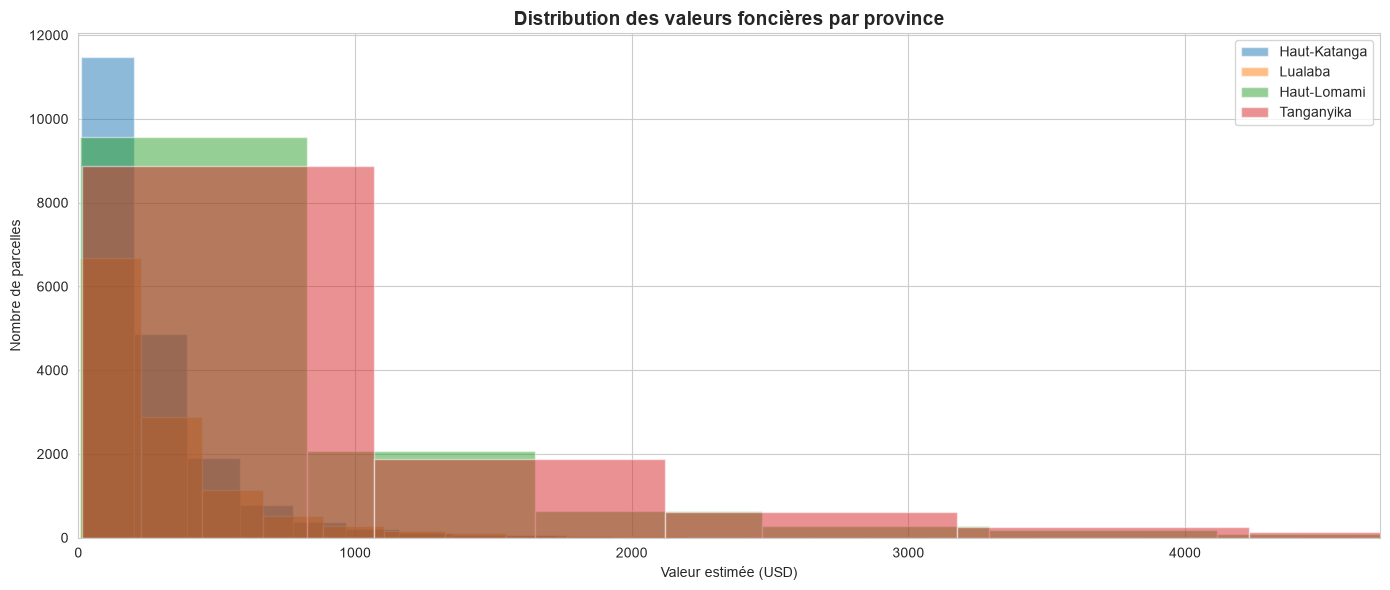

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for province in parcelles["province"].unique():
    subset = parcelles[parcelles["province"] == province]
    ax.hist(subset["valeur_usd"], bins=60, alpha=0.5, label=province)

ax.set_xlabel("Valeur estimée (USD)")
ax.set_ylabel("Nombre de parcelles")
ax.set_title("Distribution des valeurs foncières par province", fontsize=14, fontweight="bold")
ax.legend()
ax.set_xlim(0, parcelles["valeur_usd"].quantile(0.99))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "distribution_valeurs.png", dpi=150, bbox_inches="tight")
plt.show()

## **8. Matrice de corrélation**

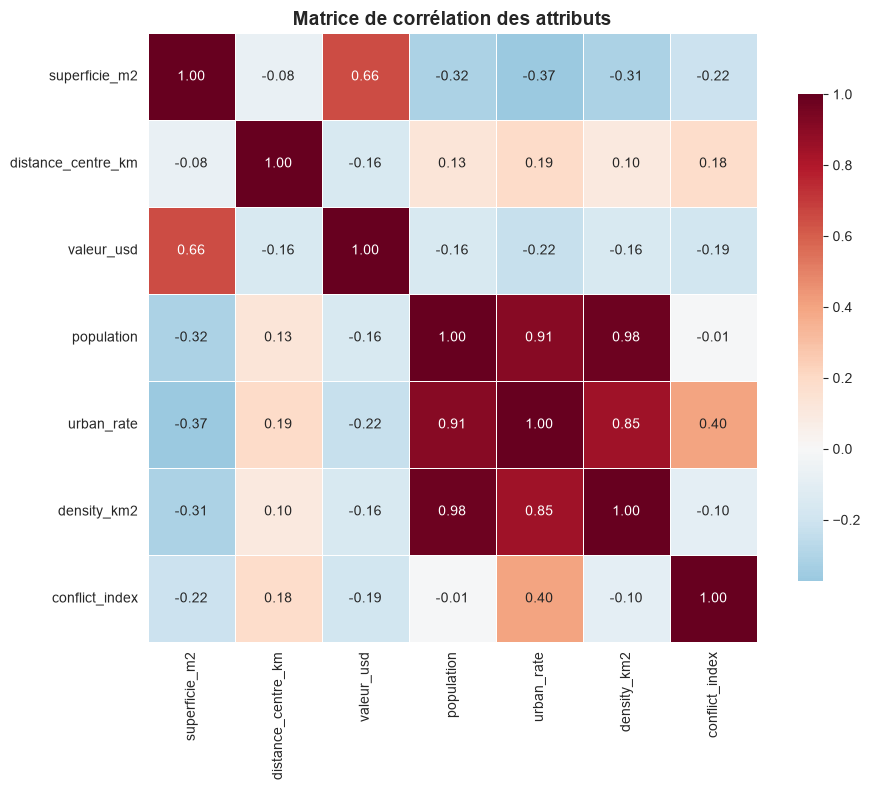

In [9]:
# Sélectionner les colonnes numériques
numeric_cols = ["superficie_m2", "distance_centre_km", "valeur_usd",
                "population", "urban_rate", "density_km2", "conflict_index"]

# Joindre les attributs provinciaux aux parcelles
parcelles_enriched = parcelles.merge(
    provinces[["adm1_name", "population", "urban_rate", "density_km2", "conflict_index"]],
    left_on="province", right_on="adm1_name", how="left"
)

corr = parcelles_enriched[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matrice de corrélation des attributs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## **9. Tableau de synthèse par province**

In [10]:
summary = parcelles.groupby("province").agg(
    n_parcelles=("id_parcelle", "count"),
    superficie_med=("superficie_m2", "median"),
    superficie_moy=("superficie_m2", "mean"),
    valeur_med=("valeur_usd", "median"),
    valeur_moy=("valeur_usd", "mean"),
    pct_formel=("statut", lambda s: (s == "formel").mean() * 100),
    pct_informel=("statut", lambda s: (s == "informel").mean() * 100),
    pct_litigieux=("statut", lambda s: (s == "litigieux").mean() * 100),
    pct_minier=("sous_influence_miniere", lambda s: s.mean() * 100),
    dist_med_km=("distance_centre_km", "median"),
).round(2)

print("=== Synthèse par province ===")
print(summary.to_string())

# Sauvegarder
summary.to_csv(PROJECT_ROOT / "data" / "synthetic" / "synthese_par_province.csv")
print(f"\n→ Sauvegardé dans data/synthetic/synthese_par_province.csv")

=== Synthèse par province ===
              n_parcelles  superficie_med  superficie_moy  valeur_med  valeur_moy  pct_formel  pct_informel  pct_litigieux  pct_minier  dist_med_km
province                                                                                                                                           
Haut-Katanga        20000          404.52          483.34      171.68      270.00       33.38         25.61          41.01       54.82       167.50
Haut-Lomami         13000         1205.16         1794.51      423.10      801.90       39.25         31.35          29.40       24.68       133.28
Lualaba             12000          789.55         1091.06      196.32      337.58       29.02         19.46          51.52       85.04       167.33
Tanganyika          12000         1502.56         2259.25      526.50     1001.12       36.13         28.52          35.34        4.77       147.63

→ Sauvegardé dans data/synthetic/synthese_par_province.csv
